Exploration de données Sujet 8

In [81]:
import pandas as pd

In [82]:
import matplotlib.pyplot as plt

In [83]:
df = pd.read_excel("Sujet8.xlsx")

In [84]:
df.head()

,user_id,age,gender,region,subscription,device_type,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
0,1,45,F,Asie,Free,Mobile,2,2.270508,33,5.977247,...,137,44,54,4,720,128.19,0.538574,2,7.627542,2.35747
1,2,32,H,Amérique,Free,DESktoP,1,31.196102,25,4.948077,...,121,43,54,15,0,110.86,0.894321,3,5.734792,78.368478
2,3,41,Autre,Afrique,Free,Mobile,1,38.464094,26,1.958113,...,87,23,30,14,165,107.6,0.740122,1,4.890083,88.838596
3,4,28,NaN,Europe,Free,Tablet,2,87.855813,36,5.015305,...,119,42,53,18,153,113.01,0.191904,3,6.314038,44.743723
4,5,30,H,Asie,Free,Tablet,2,32.797407,28,NaN,...,115,42,49,16,317,115.47,0.09866,5,7.3931,29.561283


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  4901 non-null   object
 1   age                      4882 non-null   object
 2   gender                   4877 non-null   str   
 3   region                   4893 non-null   str   
 4   subscription             4884 non-null   str   
 5   device_type              4907 non-null   str   
 6   nb_devices_used          4911 non-null   object
 7   time_on_platform         4900 non-null   object
 8   nb_sessions              4893 non-null   object
 9   avg_session_duration     4911 non-null   object
 10  premium_months           4889 non-null   object
 11  nb_friends               4911 non-null   object
 12  nb_groups                4897 non-null   object
 13  nb_pages_followed        4907 non-null   object
 14  nb_events_participated   4900 non-null   object
 15

In [86]:
df.isna()

,user_id,age,gender,region,subscription,device_type,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [87]:
df.isna().sum()

user_id                     99
age                        118
gender                     123
region                     107
subscription               116
device_type                 93
nb_devices_used             89
time_on_platform           100
nb_sessions                107
avg_session_duration        89
premium_months             111
nb_friends                  89
nb_groups                  103
nb_pages_followed           93
nb_events_participated     100
nb_searches                 89
nb_notifications_opened     98
nb_saved_posts             101
nb_reports                 101
nb_blocked_users            97
photos_posted               89
videos_posted              100
stories_posted              94
travels_shared              95
countries_visited           90
likes                       93
shares                     101
comments_written            73
reactions_given             89
reactions_received         115
messages_sent              102
messages_received           89
ads_clic

In [88]:
cols_cat = ["gender", "region", "subscription", "device_type"]

for col in cols_cat:
    df[col] = df[col].fillna("Unknown")

In [89]:
df["gender"].head(20)

0           F
1           H
2       Autre
3     Unknown
4           H
5       Autre
6           H
7       Autre
8           H
9           H
10      Autre
11      Autre
12          F
13          H
14      Autre
15          H
16          F
17      Autre
18    Autre??
19      Autre
Name: gender, dtype: str

In [90]:
df[cols_cat] = df[cols_cat].replace("Unknown", "Inconnu")

In [91]:
df["gender"].unique()

<StringArray>
[        'F',         'H',     'Autre',   'Inconnu',   'Autre??', 'undefined',
         'f',       'H??',     'AUTRE',       'F??',         'h',      'H###',
       '???',     'autrE',     'AUTre',      'F###',     'aUtRE',  'Autre###',
     'AUtRe',     'AUTrE',     'AUtrE',     'AuTrE',     'aUTrE',     'auTRe',
     'aUTre',     'AuTRE',     'AuTRe',     'aUTRE']
Length: 28, dtype: str

In [92]:
df["gender"] = df ["gender"].str.lower()

In [93]:
df["gender"] = df["gender"].str.replace(r'[?#]', '', regex=True)

In [94]:
to_replace = ['', 'undefined', '???']

In [95]:
df["gender"] = df["gender"].replace(to_replace, 'Inconnu')

In [96]:
mapping = {
    'h': 'H',
    'f': 'F',
    'autre': 'Autre',
    'inconnu': 'Inconnu'
}

In [97]:
df["gender"] = df["gender"].map(mapping).fillna('Inconnu')

In [98]:
df["gender"].unique()

<StringArray>
['F', 'H', 'Autre', 'Inconnu']
Length: 4, dtype: str

In [99]:
df["region"].unique()

<StringArray>
[       'Asie',    'Amérique',     'Afrique',      'Europe',  'Amérique??',
     'Inconnu',  'Afrique###',    'amÉrique',   'undefined',         '???',
      'Asie??',        'AsIE',    'aMÉrIque',    'AméRIQue',     'Asie###',
 'Amérique###',        'AsIe',    'AMÉrIqUe',     'aFriquE',     'AFRIquE',
    'AMérique',     'afrIQue',        'asIe',     'afrIque',        'ASIe',
    'Europe??',      'eUrOpE',      'eURope',   'Europe###',      'EUroPE',
      'EURope',        'aSiE',        'aSie',        'asiE',    'AmÉrIQuE',
   'Afrique??',      'EUrOPE',      'euROpE',      'EuRope',    'AmÉriQUE',
     'aFrIQUE',    'aMériquE',    'AMÉrIQUE',      'eUropE',      'eurOpE',
     'aFriQUE',    'AMériQUe',    'AMéRiqUe',     'afRIque',    'AméRiQue',
     'AFrIquE',      'eurOpe',     'AFrique',      'euRoPe',        'ASIE',
    'amérIQUe',      'eUrOPe',      'EurOpe',      'EuroPE',     'aFriQue']
Length: 60, dtype: str

In [100]:
df["subscription"].unique()

<StringArray>
[      'Free',    'Premium',    'Inconnu',    'Free###',       'frEe',
     'Free??',        '???',    'PREmiUm', 'Premium###',  'undefined',
       'free',  'Premium??',       'fRee',       'FrEE',       'FReE',
    'premIuM',    'PrEMIum',       'FREE',    'pREMIUM',    'PrEMium',
       'FRee',    'PreMIUm',       'fREe',    'PremIuM',    'preMIUm',
       'freE',       'FrEe',       'FreE',    'PREMIUM',    'PrEmIUm',
       'frEE',    'PReMIUM',    'pRemiUm',    'prEmIuM',    'premiUm',
    'PremIUm',       'fREE',    'prEmIum',       'fReE',    'premIum',
    'pREmIUm']
Length: 41, dtype: str

In [101]:
df["device_type"].unique()

<StringArray>
[    'Mobile',    'DESktoP',     'Tablet',    'Desktop',  'Tablet###',
     'TaBLeT',     'taBLEt',    'DeSKTop',     'mOBilE',    'Inconnu',
        '???', 'Desktop###',   'Mobile??',  'Desktop??',   'Tablet??',
    'dESKtOP',    'DESkTop',  'undefined',  'Mobile###',    'deSktoP',
     'MOBILe',    'deSkTop',     'MObIle',    'DEskTOP',     'TAbLet',
     'TABlET',    'desktOP',     'taBlET',     'MOBilE',     'moBiLE',
     'MOBiLe',     'tABLET',     'mobIlE',     'tabLET',    'DeSKTOp',
     'tablet',     'TAbLeT',     'tABlEt',     'MobilE',     'MoBiLE',
     'MobiLe',    'DESkTOP',    'deskTOp',     'TAblET',     'tAbLet',
     'tABLeT',     'TAblet',     'TabLet',    'dEsKToP',    'DeSKtOp',
    'DeSKTOP',    'DESktOP',    'desKTop',     'tABLet',    'DESKTOP',
     'MoBIle',    'dESKToP',    'DeSKtOP',    'DeSKtop',    'deSktop']
Length: 60, dtype: str

In [102]:
cols_to_clean = ["region", "subscription", "device_type"]

for col in cols_to_clean:
    df[col] = df[col].astype(str).str.lower().str.replace(r'[?#]', '', regex=True).str.strip()
    df[col] = df[col].replace(['nan', 'undefined', '', 'none', '???'], 'inconnu')

region_map = {
    'europe': 'Europe',
    'asie': 'Asie',
    'amérique': 'Amérique',
    'afrique': "Afrique",
    'inconnu': 'Inconnu'
}

sub_map = {
    'free': 'Free',
    'premium': 'Premium',
    'inconnu': 'Inconnu'
}

device_map = {
    'mobile': 'Mobile',
    'desktop': 'Desktop',
    'tablet': 'Tablet'
}

df["region"] = df["region"].map(region_map).fillna('Inconnu')
df["subscription"] = df["subscription"].map(sub_map).fillna('Inconnu')
df["device_type"] = df["device_type"].map(device_map).fillna('Inconnu')
    

In [103]:
df["region"].unique()

<StringArray>
['Asie', 'Amérique', 'Afrique', 'Europe', 'Inconnu']
Length: 5, dtype: str

In [104]:
df["subscription"].unique()

<StringArray>
['Free', 'Premium', 'Inconnu']
Length: 3, dtype: str

In [105]:
df["device_type"].unique()

<StringArray>
['Mobile', 'Desktop', 'Tablet', 'Inconnu']
Length: 4, dtype: str

In [106]:
cols_num = df.select_dtypes(include=["float64", "int64"]).columns
for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

In [107]:
df[cols_num].isna().sum()

Series([], dtype: float64)

In [108]:
df.dtypes

user_id                    object
age                        object
gender                        str
region                        str
subscription                  str
device_type                   str
nb_devices_used            object
time_on_platform           object
nb_sessions                object
avg_session_duration       object
premium_months             object
nb_friends                 object
nb_groups                  object
nb_pages_followed          object
nb_events_participated     object
nb_searches                object
nb_notifications_opened    object
nb_saved_posts             object
nb_reports                 object
nb_blocked_users           object
photos_posted              object
videos_posted              object
stories_posted             object
travels_shared             object
countries_visited          object
likes                      object
shares                     object
comments_written           object
reactions_given            object
reactions_rece

In [109]:
cols_num = [
    "age", "nb_devices_used", "time_on_platform", "nb_sessions",
    "avg_session_duration", "premium_months", "nb_friends",
    "nb_groups", "nb_pages_followed", "nb_events_participated",
    "nb_searches", "nb_notifications_opened", "nb_saved_posts",
    "nb_reports", "nb_blocked_users", "photos_posted",
    "videos_posted", "stories_posted", "travels_shared",
    "countries_visited", "likes", "shares", "comments_written",
    "reactions_given", "reactions_received", "messages_sent",
    "messages_received", "ads_clicked", "video_views",
    "engagement_score", "churn_risk", "satisfaction",
    "geo_lat", "geo_lon"
]

In [110]:
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [111]:
df[cols_num].dtypes

age                        float64
nb_devices_used            float64
time_on_platform           float64
nb_sessions                float64
avg_session_duration       float64
premium_months             float64
nb_friends                 float64
nb_groups                  float64
nb_pages_followed          float64
nb_events_participated     float64
nb_searches                float64
nb_notifications_opened    float64
nb_saved_posts             float64
nb_reports                 float64
nb_blocked_users           float64
photos_posted              float64
videos_posted              float64
stories_posted             float64
travels_shared             float64
countries_visited          float64
likes                      float64
shares                     float64
comments_written           float64
reactions_given            float64
reactions_received         float64
messages_sent              float64
messages_received          float64
ads_clicked                float64
video_views         

In [112]:
for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

In [113]:
df[cols_num].isna().sum()

age                        0
nb_devices_used            0
time_on_platform           0
nb_sessions                0
avg_session_duration       0
premium_months             0
nb_friends                 0
nb_groups                  0
nb_pages_followed          0
nb_events_participated     0
nb_searches                0
nb_notifications_opened    0
nb_saved_posts             0
nb_reports                 0
nb_blocked_users           0
photos_posted              0
videos_posted              0
stories_posted             0
travels_shared             0
countries_visited          0
likes                      0
shares                     0
comments_written           0
reactions_given            0
reactions_received         0
messages_sent              0
messages_received          0
ads_clicked                0
video_views                0
engagement_score           0
churn_risk                 0
satisfaction               0
geo_lat                    0
geo_lon                    0
dtype: int64

In [114]:
df[cols_num].describe()

,age,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,premium_months,nb_friends,nb_groups,nb_pages_followed,nb_events_participated,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,41.945228,2.053454,62.762334,30.583851,5.104051,5.458797,153.771094,5.197686,20.625360,2.027887,...,121.029545,41.168419,50.840550,15.953694,385.966432,112.192986,0.500988,3.150795,40.871210,47.134289
std,25.778255,1.293660,77.705950,14.869988,3.056791,11.025287,81.635434,4.083932,13.439633,1.772026,...,47.957178,23.067126,25.111231,10.966539,352.836778,65.049915,0.410082,2.832665,30.949508,47.016020
min,-1.000000,-1.000000,-1.000000,-1.000000,-2.110610,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-4.616363
25%,30.000000,1.000000,18.621420,26.000000,4.021963,0.000000,141.000000,3.000000,17.000000,1.000000,...,112.000000,36.000000,45.000000,12.000000,153.750000,99.027500,0.250628,2.000000,21.299288,16.544502
50%,41.945228,2.000000,45.303275,30.000000,5.053607,0.000000,150.000000,5.000000,20.000000,2.000000,...,120.000000,40.000000,50.000000,16.000000,339.000000,108.795000,0.500988,3.000000,40.806036,44.329272
75%,52.000000,3.000000,84.061755,33.000000,5.987652,5.458797,157.250000,6.000000,23.000000,3.000000,...,127.000000,44.000000,55.000000,19.000000,556.000000,117.615000,0.736996,4.000000,57.990530,73.816753
max,620.000000,30.000000,1980.845416,380.000000,83.135352,310.000000,1650.000000,110.000000,280.000000,60.000000,...,1380.000000,480.000000,630.000000,230.000000,9810.000000,1353.800000,9.611332,50.000000,750.682196,995.638623


In [115]:
df.loc[df["age"] < 0, "age"] = None
df.loc[df["age"] > 100, "age"] = None

In [116]:
df["age"] = df["age"].fillna(df["age"].mean())

In [117]:
df["age"].describe()

count    5000.000000
mean       40.937466
std        13.424788
min         0.000000
25%        30.000000
50%        41.945228
75%        52.000000
max        64.000000
Name: age, dtype: float64

In [118]:
df[[
    "time_on_platform",
    "avg_session_duration",
    "nb_sessions",
    "nb_friends",
    "engagement_score",
    "churn_risk",
    "satisfaction",
    "geo_lat",
    "geo_lon"
]].describe()

,time_on_platform,avg_session_duration,nb_sessions,nb_friends,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,62.762334,5.104051,30.583851,153.771094,112.192986,0.500988,3.150795,40.871210,47.134289
std,77.705950,3.056791,14.869988,81.635434,65.049915,0.410082,2.832665,30.949508,47.016020
min,-1.000000,-2.110610,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-4.616363
25%,18.621420,4.021963,26.000000,141.000000,99.027500,0.250628,2.000000,21.299288,16.544502
50%,45.303275,5.053607,30.000000,150.000000,108.795000,0.500988,3.000000,40.806036,44.329272
75%,84.061755,5.987652,33.000000,157.250000,117.615000,0.736996,4.000000,57.990530,73.816753
max,1980.845416,83.135352,380.000000,1650.000000,1353.800000,9.611332,50.000000,750.682196,995.638623


In [119]:
cols_positive = [
    "time_on_platform", "avg_session_duration", "nb_sessions",
    "nb_friends", "engagement_score", "churn_risk", "satisfaction"
]

for col in cols_positive:
    df.loc[df[col] < 0, col] = None

In [120]:
df.loc[(df["geo_lat"] < -90) | (df["geo_lat"] > 90), "geo_lat"] = None
df.loc[(df["geo_lon"] < -180) | (df["geo_lon"] > 180), "geo_lon"] = None

In [121]:
for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

In [122]:
df.loc[(df["churn_risk"] < 0) | (df["churn_risk"] > 1), "churn_risk"] = None

In [123]:
df.loc[(df["satisfaction"] < 1) | (df["satisfaction"] > 5), "satisfaction"] = None

In [124]:
for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

In [125]:
df = df.replace("#", "", regex=True)

In [126]:
corr = df.corr(numeric_only=True)
print(corr)

                              age  nb_devices_used  time_on_platform  \
age                      1.000000         0.047563          0.003624   
nb_devices_used          0.047563         1.000000          0.012217   
time_on_platform         0.003624         0.012217          1.000000   
nb_sessions              0.016047         0.027770          0.000663   
avg_session_duration    -0.007424        -0.010204         -0.003496   
premium_months          -0.019946        -0.005738         -0.004989   
nb_friends               0.010004         0.025796         -0.002721   
nb_groups                0.001101        -0.016423          0.000074   
nb_pages_followed       -0.003954        -0.005016         -0.013032   
nb_events_participated   0.006315        -0.006511          0.005614   
nb_searches             -0.011868        -0.005904         -0.015767   
nb_notifications_opened  0.025735         0.005750          0.001115   
nb_saved_posts           0.021629        -0.009299          0.00

In [127]:
for col in cols_num:
    try:
        pd.to_numeric(df[col], errors="raise")
    except Exception as e:
        print(f"Problème dans {col} : {e}")

In [128]:
for col in cols_num:
    df[col] = df[col].astype(str).str.replace(r"[^0-9.\-]", "", regex=True)

for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

corr_matrix = df[cols_num].corr(method="spearman")

In [129]:
corr_matrix = df[cols_num].corr(method="spearman")
corr_matrix.head()

,age,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,premium_months,nb_friends,nb_groups,nb_pages_followed,nb_events_participated,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
age,1.000000,0.026066,0.004835,0.011272,0.008086,-0.012873,0.001316,0.005345,-0.002110,-0.007711,...,0.006548,0.019183,0.023395,0.004116,0.750510,-0.011652,-0.014150,0.008789,0.003208,-0.014975
nb_devices_used,0.026066,1.000000,-0.000812,0.020658,-0.010697,0.013866,0.017399,-0.020619,0.015313,-0.012290,...,-0.020225,0.015188,0.001490,-0.004142,0.016041,0.002648,-0.017814,-0.009931,0.018308,0.018539
time_on_platform,0.004835,-0.000812,1.000000,0.005951,0.008914,-0.006504,-0.016096,-0.007329,0.008235,-0.002648,...,0.011133,0.027775,0.021760,0.907903,0.005184,-0.017926,-0.013765,-0.011494,0.000854,0.014931
nb_sessions,0.011272,0.020658,0.005951,1.000000,-0.020919,-0.021072,0.012768,-0.000120,-0.030195,-0.019509,...,0.015991,-0.009262,-0.005064,0.011492,0.005040,0.071174,0.001048,0.010620,-0.020883,-0.008029
avg_session_duration,0.008086,-0.010697,0.008914,-0.020919,1.000000,-0.002562,-0.013775,-0.008434,-0.014089,0.006050,...,-0.008245,0.014508,0.011196,0.009349,0.011270,-0.008455,0.036889,0.003063,-0.010612,0.017851


In [130]:
df.dtypes

user_id                     object
age                        float64
gender                         str
region                         str
subscription                   str
device_type                    str
nb_devices_used            float64
time_on_platform           float64
nb_sessions                float64
avg_session_duration       float64
premium_months             float64
nb_friends                 float64
nb_groups                  float64
nb_pages_followed          float64
nb_events_participated     float64
nb_searches                float64
nb_notifications_opened    float64
nb_saved_posts             float64
nb_reports                 float64
nb_blocked_users           float64
photos_posted              float64
videos_posted              float64
stories_posted             float64
travels_shared             float64
countries_visited          float64
likes                      float64
shares                     float64
comments_written           float64
reactions_given     

In [131]:
for col in cols_num:
    df[col] = df[col].astype(str).str.replace(r"[^0-9.\-]", "", regex=True)

for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

In [132]:
df[cols_num].dtypes

age                        float64
nb_devices_used            float64
time_on_platform           float64
nb_sessions                float64
avg_session_duration       float64
premium_months             float64
nb_friends                 float64
nb_groups                  float64
nb_pages_followed          float64
nb_events_participated     float64
nb_searches                float64
nb_notifications_opened    float64
nb_saved_posts             float64
nb_reports                 float64
nb_blocked_users           float64
photos_posted              float64
videos_posted              float64
stories_posted             float64
travels_shared             float64
countries_visited          float64
likes                      float64
shares                     float64
comments_written           float64
reactions_given            float64
reactions_received         float64
messages_sent              float64
messages_received          float64
ads_clicked                float64
video_views         

In [133]:
corr_matrix = df[cols_num].corr(method="spearman")
corr_matrix

,age,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,premium_months,nb_friends,nb_groups,nb_pages_followed,nb_events_participated,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
age,1.000000,0.026066,0.004835,0.011272,0.008086,-0.012873,0.001316,0.005345,-0.002110,-0.007711,...,0.006548,0.019183,0.023395,0.004116,0.750510,-0.011652,-0.014150,0.008789,0.003208,-0.014975
nb_devices_used,0.026066,1.000000,-0.000812,0.020658,-0.010697,0.013866,0.017399,-0.020619,0.015313,-0.012290,...,-0.020225,0.015188,0.001490,-0.004142,0.016041,0.002648,-0.017814,-0.009931,0.018308,0.018539
time_on_platform,0.004835,-0.000812,1.000000,0.005951,0.008914,-0.006504,-0.016096,-0.007329,0.008235,-0.002648,...,0.011133,0.027775,0.021760,0.907903,0.005184,-0.017926,-0.013765,-0.011494,0.000854,0.014931
nb_sessions,0.011272,0.020658,0.005951,1.000000,-0.020919,-0.021072,0.012768,-0.000120,-0.030195,-0.019509,...,0.015991,-0.009262,-0.005064,0.011492,0.005040,0.071174,0.001048,0.010620,-0.020883,-0.008029
avg_session_duration,0.008086,-0.010697,0.008914,-0.020919,1.000000,-0.002562,-0.013775,-0.008434,-0.014089,0.006050,...,-0.008245,0.014508,0.011196,0.009349,0.011270,-0.008455,0.036889,0.003063,-0.010612,0.017851
premium_months,-0.012873,0.013866,-0.006504,-0.021072,-0.002562,1.000000,-0.015799,0.012290,-0.023822,0.019299,...,0.003056,0.025344,0.021607,-0.013174,0.004426,-0.002567,-0.012586,-0.013970,-0.009451,-0.004076
nb_friends,0.001316,0.017399,-0.016096,0.012768,-0.013775,-0.015799,1.000000,-0.016455,0.008157,-0.006503,...,0.011025,-0.000299,0.000766,-0.012344,-0.001284,-0.022012,-0.022079,-0.007381,0.009917,-0.022404
nb_groups,0.005345,-0.020619,-0.007329,-0.000120,-0.008434,0.012290,-0.016455,1.000000,0.008739,0.004241,...,0.014820,-0.006418,-0.005037,0.003080,0.006302,0.003598,-0.015030,-0.005357,-0.001169,0.019375
nb_pages_followed,-0.002110,0.015313,0.008235,-0.030195,-0.014089,-0.023822,0.008157,0.008739,1.000000,-0.000707,...,-0.018625,0.007393,0.003093,0.005317,-0.006256,-0.001974,0.009814,-0.019664,-0.029147,-0.007478
nb_events_participated,-0.007711,-0.012290,-0.002648,-0.019509,0.006050,0.019299,-0.006503,0.004241,-0.000707,1.000000,...,0.003936,-0.021363,-0.007972,0.000525,0.011085,0.029203,-0.032374,-0.002363,-0.007596,-0.014663


In [134]:
df[cols_num].apply(lambda s: s.astype(str).str.contains("[A-Za-z#]", regex=True).sum())

age                        0
nb_devices_used            0
time_on_platform           0
nb_sessions                0
avg_session_duration       0
premium_months             0
nb_friends                 0
nb_groups                  0
nb_pages_followed          0
nb_events_participated     0
nb_searches                0
nb_notifications_opened    0
nb_saved_posts             0
nb_reports                 0
nb_blocked_users           0
photos_posted              0
videos_posted              0
stories_posted             0
travels_shared             0
countries_visited          0
likes                      0
shares                     0
comments_written           0
reactions_given            0
reactions_received         0
messages_sent              0
messages_received          0
ads_clicked                0
video_views                0
engagement_score           0
churn_risk                 0
satisfaction               0
geo_lat                    0
geo_lon                    0
dtype: int64

In [135]:
relations = [
    ("age", "video_views"),
    ("time_on_platform", "ads_clicked"),
    ("age", "nb_friends"),           
    ("age", "satisfaction"), 
    ("photos_posted", "likes"),
    ("photos_posted", "engagement_score"),
    ("nb_sessions", "engagement_score"),  
    ("time_on_platform", "nb_friends"),
    ("likes", "engagement_score"),
    ("reactions_given", "reactions_received"),
    ("premium_months", "satisfaction"),
    ("messages_sent", "messages_received"),
    ("geo_lat", "geo_lon")
]

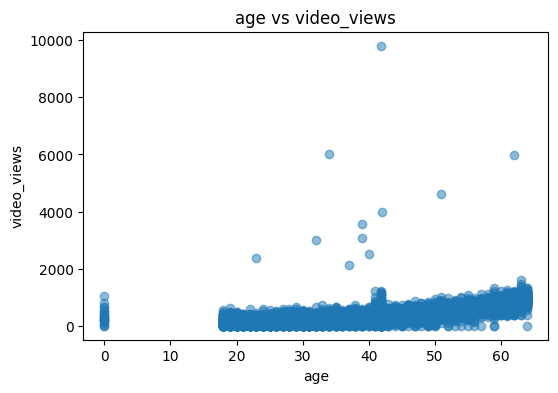

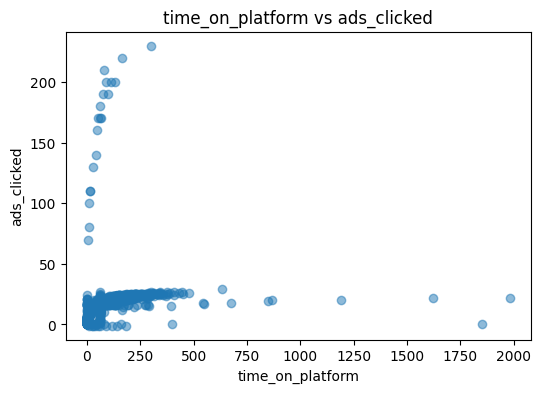

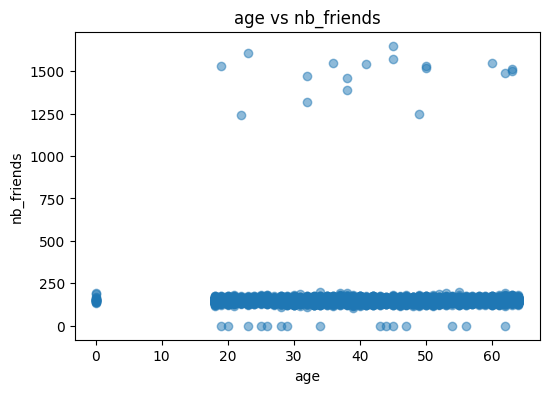

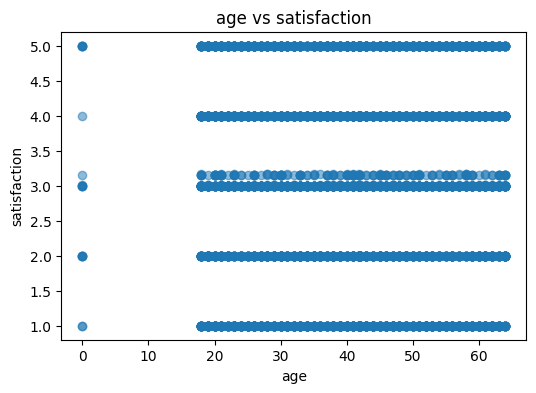

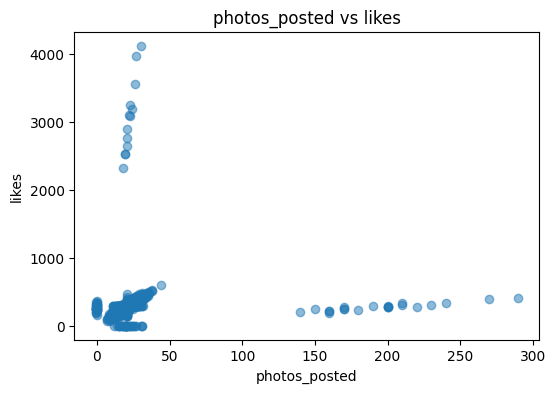

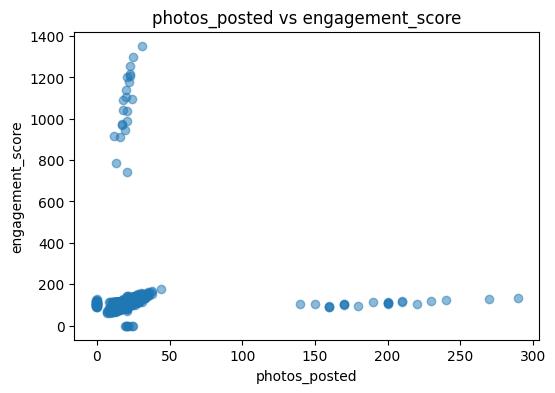

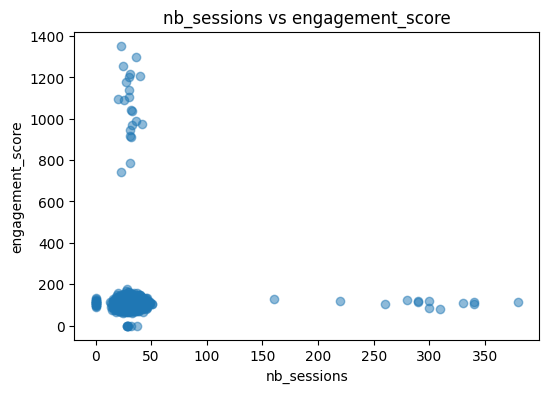

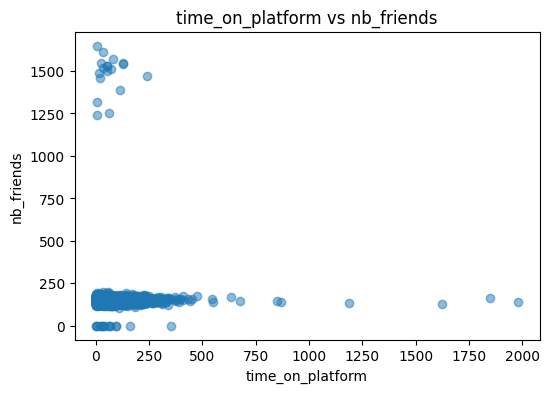

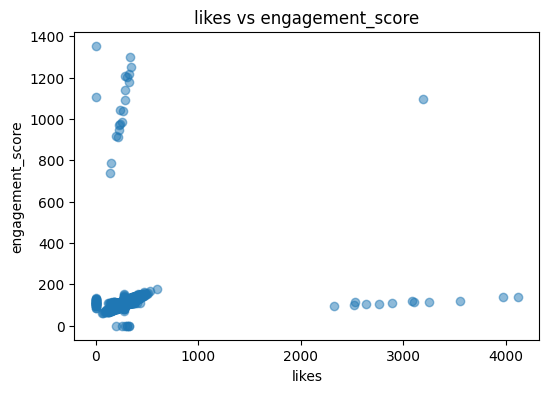

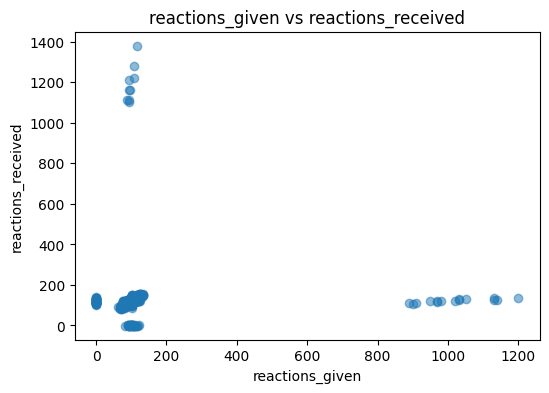

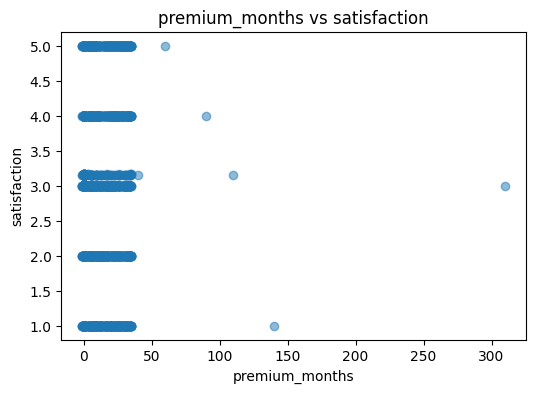

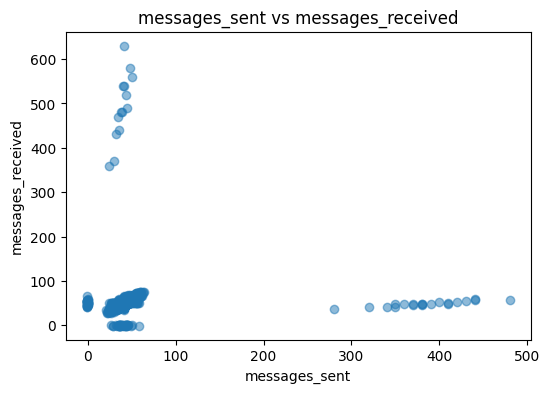

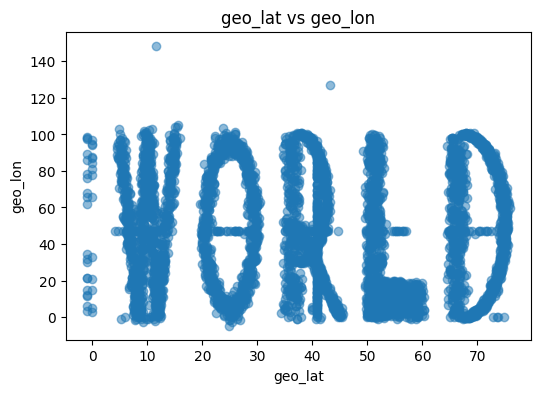

In [136]:
for x, y in relations:
    plt.figure(figsize=(6,4))
    
    plt.scatter(df[x], df[y], alpha=0.5)
    
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    
    plt.show()

In [137]:
for x, y in relations:
    r = corr_matrix.loc[x, y]
    if abs(r) > 0.5:
        print(f"{x} - {y} : {r:.3f}")
    else:
        print(f"{x} - {y} : {r:.3f}  — pas de corrélation significative")

age - video_views : 0.751
time_on_platform - ads_clicked : 0.908
age - nb_friends : 0.001  — pas de corrélation significative
age - satisfaction : 0.009  — pas de corrélation significative
photos_posted - likes : 0.867
photos_posted - engagement_score : 0.820
nb_sessions - engagement_score : 0.071  — pas de corrélation significative
time_on_platform - nb_friends : -0.016  — pas de corrélation significative
likes - engagement_score : 0.882
reactions_given - reactions_received : 0.844
premium_months - satisfaction : -0.014  — pas de corrélation significative
messages_sent - messages_received : 0.820
geo_lat - geo_lon : -0.090  — pas de corrélation significative


In [138]:
cols = corr_matrix.columns.tolist()
for i, col1 in enumerate(cols):
    for col2 in cols[i+1:]:
        if abs(corr_matrix.loc[col1, col2]) > 0.5:
            print(col1, "-", col2, ":", round(corr_matrix.loc[col1, col2], 3))

age - video_views : 0.751
time_on_platform - ads_clicked : 0.908
photos_posted - likes : 0.867
photos_posted - engagement_score : 0.82
likes - engagement_score : 0.882
reactions_given - reactions_received : 0.844
messages_sent - messages_received : 0.82
